# Analysis Notebook for ACL Paper

This notebook computes statistics and generates tables/figures for the paper.

**Data sources:**
- `Data/narratives/*.csv` - Generated NLEs (9 strategies) - for **efficiency** analysis
- `Data/forsetzung_results/*/geval_*.csv` - G-Eval scores - for **quality** analysis

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
NARRATIVES_DIR = Path("../../Data/narratives")
EVAL_DIR = Path("../../Data/forsetzung_results/20250813_135743")

print(f"Narratives dir exists: {NARRATIVES_DIR.exists()}")
print(f"Evaluation dir exists: {EVAL_DIR.exists()}")

Narratives dir exists: True
Evaluation dir exists: True


In [16]:
# Load all narrative files (GENERATION data, not evaluation)
NARRATIVES_DIR = Path("../../Data/narratives")

dfs = []
for csv_file in sorted(NARRATIVES_DIR.glob("*.csv")):
    strategy = csv_file.stem  # filename = strategy name
    temp_df = pd.read_csv(csv_file)
    temp_df['Strategy'] = strategy
    dfs.append(temp_df)
    print(f"Loaded {strategy}: {len(temp_df)} rows")

df_all = pd.concat(dfs, ignore_index=True)

# Separate main analysis from temperature sweep
df = df_all[df_all['Strategy'] != 'zero_shot_temp'].copy()
df_temp = df_all[df_all['Strategy'] == 'zero_shot_temp'].copy()

print(f"\n{'='*50}")
print(f"Total rows: {len(df_all):,}")
print(f"Main analysis (excl. temp sweep): {len(df):,}")
print(f"Temperature sweep: {len(df_temp):,}")

print(f"\nFactors in main analysis:")
for col in ['LLM', 'Model', 'XAI', 'Strategy']:
    print(f"  {col}: {df[col].nunique()} levels - {sorted(df[col].unique())}")

Loaded cot_few_shot: 60 rows
Loaded cot_zero_shot: 60 rows
Loaded few_shot: 90 rows
Loaded meta_prompting: 90 rows
Loaded reflexion: 90 rows
Loaded role_based: 90 rows
Loaded self_consistency: 90 rows
Loaded zero_shot: 90 rows
Loaded zero_shot_temp: 1890 rows

Total rows: 2,550
Main analysis (excl. temp sweep): 660
Temperature sweep: 1,890

Factors in main analysis:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


---

## 3. Quality Analysis (G-Eval Scores)

Now we load the **evaluation** data - G-Eval scores from both judges (GPT-4 and DeepSeek-R1).

**4 Evaluation Dimensions** (1-5 scale):
1. `accuracy` - Faithfulness to XAI outputs and factual correctness
2. `lay_user_relevancy` - Accessibility for non-experts
3. `expert_relevancy` - Technical depth for domain experts
4. `explanation_helpfulness` - Overall usefulness of the explanation

*Note: Prediction Closeness dimension was excluded from analysis as it conflates explanation quality with prediction accuracy.*

In [17]:
# Load G-Eval evaluation data from BOTH judges
geval_gpt4_raw = pd.read_csv(EVAL_DIR / "geval_gpt4.csv")
geval_deepseek_raw = pd.read_csv(EVAL_DIR / "geval_deepseek.csv")

# GPT-4 has token probability scores (g_eval_score)
# DeepSeek only has traditional scores (no logprobs API access)
# We'll create unified score columns for both

# Score column suffixes - 4 dimensions (Prediction Closeness excluded)
DIMS = ['accuracy', 'lay_user_relevancy', 'expert_relevancy', 
        'usefulness_explanation_helpfulness']

# Shorter names for display
DIM_NAMES = {
    'accuracy': 'Accuracy',
    'lay_user_relevancy': 'Lay Relevancy',
    'expert_relevancy': 'Expert Relevancy',
    'usefulness_explanation_helpfulness': 'Helpfulness'
}

# Create unified score columns
# GPT-4: use g_eval_score (token probability based)
# DeepSeek: use traditional_score (parsing-based)
geval_gpt4 = geval_gpt4_raw.copy()
geval_deepseek = geval_deepseek_raw.copy()

SCORE_COLS = []
for dim in DIMS:
    unified_col = f'score_{dim}'
    SCORE_COLS.append(unified_col)
    
    # GPT-4: prefer g_eval_score
    gpt4_col = f'eval_{dim}_g_eval_score'
    geval_gpt4[unified_col] = geval_gpt4_raw[gpt4_col]
    
    # DeepSeek: use traditional_score
    ds_col = f'eval_{dim}_traditional_score'
    geval_deepseek[unified_col] = geval_deepseek_raw[ds_col]

# Factor columns
FACTOR_COLS = ['LLM', 'Model', 'XAI', 'Strategy']

print(f"GPT-4 Judge: {len(geval_gpt4)} rows (using g_eval_score - token probabilities)")
print(f"DeepSeek Judge: {len(geval_deepseek)} rows (using traditional_score - no logprobs)")

print(f"\nEvaluation Dimensions (4):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: GPT4 {geval_gpt4[col].min():.1f}-{geval_gpt4[col].max():.1f}, DS {geval_deepseek[col].min():.1f}-{geval_deepseek[col].max():.1f}")

print(f"\nFactors in evaluation data:")
for col in FACTOR_COLS:
    print(f"  {col}: {geval_gpt4[col].nunique()} levels - {sorted(geval_gpt4[col].unique())}")

GPT-4 Judge: 660 rows (using g_eval_score - token probabilities)
DeepSeek Judge: 660 rows (using traditional_score - no logprobs)

Evaluation Dimensions (4):
  Accuracy: GPT4 2.0-5.0, DS 1.0-5.0
  Lay Relevancy: GPT4 3.0-5.0, DS 3.0-5.0
  Expert Relevancy: GPT4 2.0-5.0, DS 2.0-5.0
  Helpfulness: GPT4 2.0-5.0, DS 2.0-5.0

Factors in evaluation data:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


In [18]:
# Check sample sizes per condition
print("Sample sizes by condition (GPT-4 judge):\n")

# Overall counts by each factor
for col in FACTOR_COLS:
    print(f"\n{col}:")
    counts = geval_gpt4.groupby(col).size().sort_values(ascending=False)
    for level, n in counts.items():
        print(f"  {level}: {n}")

# Cross-tabulation: LLM × Strategy (to see which combinations exist)
print("\n" + "="*60)
print("Cross-tabulation: LLM × Strategy")
print("="*60)
ct = pd.crosstab(geval_gpt4['LLM'], geval_gpt4['Strategy'])
display(ct)

# Check: do CoT strategies exclude DeepSeek?
print("\nNote: CoT strategies exclude DeepSeek-R1 (native reasoning model)")
cot_strategies = [s for s in geval_gpt4['Strategy'].unique() if 'cot' in s.lower()]
print(f"CoT strategies: {cot_strategies}")

Sample sizes by condition (GPT-4 judge):


LLM:
  GPT: 240
  L3_LOCAL: 240
  DEEPSEEK: 180

Model:
  MLP: 198
  RandomForest: 198
  XGB: 198
  SARIMAX: 66

XAI:
  none: 264
  lime: 198
  shap: 198

Strategy:
  meta_prompting: 90
  few_shot: 90
  role_based: 90
  reflexion: 90
  self_consistency: 90
  zero_shot: 90
  cot_few_shot: 60
  cot_zero_shot: 60

Cross-tabulation: LLM × Strategy


Strategy,cot_few_shot,cot_zero_shot,few_shot,meta_prompting,reflexion,role_based,self_consistency,zero_shot
LLM,,,,,,,,
DEEPSEEK,0,0,30,30,30,30,30,30
GPT,30,30,30,30,30,30,30,30
L3_LOCAL,30,30,30,30,30,30,30,30



Note: CoT strategies exclude DeepSeek-R1 (native reasoning model)
CoT strategies: ['cot_few_shot', 'cot_zero_shot']


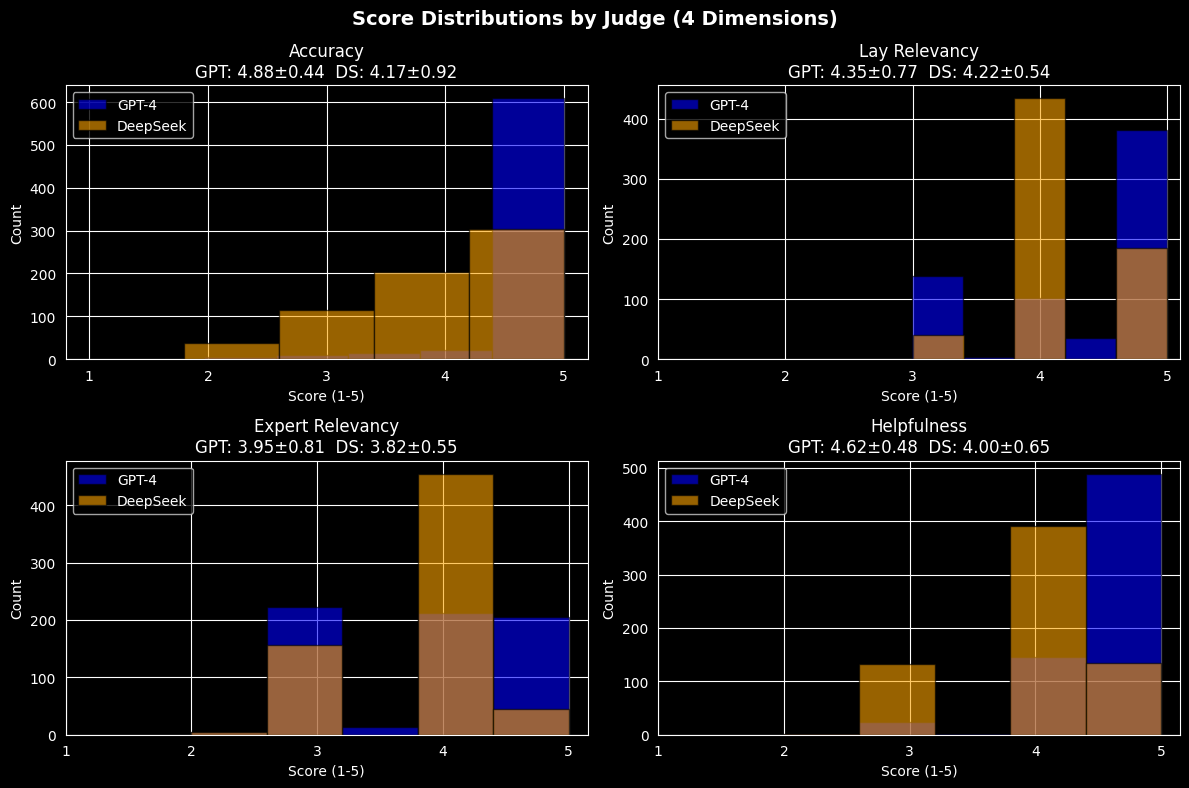


Summary Statistics (GPT-4 Judge):
----------------------------------------------------------------------


,dimension,count,mean,std,min,25%,50%,75%,max
score_accuracy,Accuracy,660.0,4.88,0.44,1.97,5.00,5.00,5.00,5.0
score_lay_user_relevancy,Lay Relevancy,660.0,4.35,0.77,2.99,4.00,4.83,4.98,5.0
score_expert_relevancy,Expert Relevancy,660.0,3.95,0.81,2.00,3.00,3.99,4.98,5.0
score_usefulness_explanation_helpfulness,Helpfulness,660.0,4.62,0.48,2.00,4.37,4.85,4.98,5.0


In [19]:
# Score distributions - Check for ceiling effects
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    dim = col.replace('score_', '')
    dim_name = DIM_NAMES[dim]
    
    # Both judges on same plot
    ax.hist(geval_gpt4[col].dropna(), bins=5, alpha=0.6, label='GPT-4', color='blue', edgecolor='black')
    ax.hist(geval_deepseek[col].dropna(), bins=5, alpha=0.6, label='DeepSeek', color='orange', edgecolor='black')
    
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Count')
    ax.set_title(f'{dim_name}\nGPT: {geval_gpt4[col].mean():.2f}±{geval_gpt4[col].std():.2f}  DS: {geval_deepseek[col].mean():.2f}±{geval_deepseek[col].std():.2f}')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend()

plt.suptitle('Score Distributions by Judge (4 Dimensions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\nSummary Statistics (GPT-4 Judge):")
print("-" * 70)
summary = geval_gpt4[SCORE_COLS].describe().T
summary['dimension'] = [DIM_NAMES[c.replace('score_', '')] for c in summary.index]
summary = summary[['dimension', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary.round(2))

### 3.1 Merge Both Judges

We average scores from GPT-4 and DeepSeek judges for each explanation to mitigate potential self-preference bias (LLM judges may favor explanations from their own model family).

In [20]:
# Merge both judges by averaging their scores
# Both dataframes have the same rows in the same order (same 660 explanations)

df_eval = geval_gpt4[FACTOR_COLS].copy()  # Keep factor columns from one

# Average scores from both judges for each dimension
for col in SCORE_COLS:
    df_eval[col] = (geval_gpt4[col] + geval_deepseek[col]) / 2

# Verify
print("Merged evaluation dataset:")
print(f"  Rows: {len(df_eval)}")
print(f"  Factors: {FACTOR_COLS}")
print(f"  Score columns: {SCORE_COLS}")

print(f"\nScore ranges (averaged across both judges):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: {df_eval[col].min():.2f} - {df_eval[col].max():.2f} (mean: {df_eval[col].mean():.2f})")

Merged evaluation dataset:
  Rows: 660
  Factors: ['LLM', 'Model', 'XAI', 'Strategy']
  Score columns: ['score_accuracy', 'score_lay_user_relevancy', 'score_expert_relevancy', 'score_usefulness_explanation_helpfulness']

Score ranges (averaged across both judges):
  Accuracy: 1.98 - 5.00 (mean: 4.52)
  Lay Relevancy: 3.00 - 5.00 (mean: 4.29)
  Expert Relevancy: 2.50 - 5.00 (mean: 3.88)
  Helpfulness: 2.49 - 5.00 (mean: 4.31)


In [21]:
# Statistical Helper Functions
# ============================

import subprocess, sys
for pkg in ['scipy', 'statsmodels', 'pingouin']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import pingouin as pg

# --- Effect Size Functions ---

def cohens_d(g1, g2):
    """Cohen's d effect size for two groups."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(), g2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0

def omega_squared(f_stat, df_between, df_within, n_total):
    """
    Omega-squared (ω²) - less biased omnibus effect size for ANOVA.
    Interpretation: 0.01 = small, 0.06 = medium, 0.14 = large
    """
    ss_between = f_stat * df_between * (df_within / (n_total - df_between - 1))
    ms_within = df_within / (n_total - df_between - 1)
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + (n_total - df_between) * ms_within + ms_within)
    return max(0, omega_sq)  # Can be negative for very small effects

def omega_sq_from_anova(*groups):
    """Compute omega-squared directly from group data."""
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    df_between = k - 1
    df_within = n_total - k
    
    # Compute SS
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_within = sum(((g - g.mean())**2).sum() for g in groups)
    
    ms_within = ss_within / df_within
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + ss_within + ms_within)
    return max(0, omega_sq)

def effect_label(d):
    """Interpret Cohen's d."""
    d = abs(d)
    if d < 0.2: return "negl."
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

def omega_label(w2):
    """Interpret omega-squared."""
    if w2 < 0.01: return "negl."
    elif w2 < 0.06: return "small"
    elif w2 < 0.14: return "medium"
    else: return "large"

# --- FDR Correction ---

def fdr_correct(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction.
    Returns: corrected p-values, reject array
    """
    reject, p_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    return p_corrected, reject

# --- Welch ANOVA + Games-Howell ---

def welch_anova(data, dv, between):
    """
    Welch's ANOVA - robust to unequal variances.
    Returns F, p, omega-squared
    """
    result = pg.welch_anova(data=data, dv=dv, between=between)
    return result

def games_howell(data, dv, between):
    """
    Games-Howell post-hoc test - robust to unequal variances and sample sizes.
    """
    result = pg.pairwise_gameshowell(data=data, dv=dv, between=between)
    return result

print("Statistical helper functions loaded:")
print("  - cohens_d(g1, g2): Cohen's d effect size")
print("  - omega_sq_from_anova(*groups): ω² omnibus effect size")
print("  - effect_label(d), omega_label(w2): Interpret effect sizes")
print("  - fdr_correct(p_values): Benjamini-Hochberg FDR correction")
print("  - welch_anova(data, dv, between): Welch's ANOVA (robust)")
print("  - games_howell(data, dv, between): Games-Howell post-hoc (robust)")

Statistical helper functions loaded:
  - cohens_d(g1, g2): Cohen's d effect size
  - omega_sq_from_anova(*groups): ω² omnibus effect size
  - effect_label(d), omega_label(w2): Interpret effect sizes
  - fdr_correct(p_values): Benjamini-Hochberg FDR correction
  - welch_anova(data, dv, between): Welch's ANOVA (robust)
  - games_howell(data, dv, between): Games-Howell post-hoc (robust)


---

## 4. RQ1: Effect of XAI Method on NLE Quality

**Research Question**: Does incorporating XAI (SHAP/LIME) improve the quality of generated explanations compared to no XAI?

**Design**: 3 XAI conditions (SHAP, LIME, None) × 594 explanations (excluding SARIMAX for balanced design, N=198 per group)

---

### Statistical Analysis Pipeline (Standardized)

Following our standardized methodology (see Appendix E.1):

1. **One-way ANOVA** with ω² effect sizes
2. **Pairwise t-tests** with Cohen's d and FDR correction
3. **Welch ANOVA** (robustness check)
4. **Games-Howell post-hoc** (robust to unequal variances)
5. **Factorial Model** (controlling for LLM & Strategy)
6. **Interaction Tests**: XAI × LLM, XAI × Model, XAI × Strategy
7. **Simple Effects** (for significant interactions)

---

### Key Results

**Main Finding**: XAI significantly improves only **Expert Relevancy**; all other dimensions show no effect.

| Dimension | F | p | ω² | Effect |
|-----------|---|---|-----|--------|
| Accuracy | 1.07 | .342 | .000 | negl. |
| Lay Relevancy | 0.00 | .999 | .000 | negl. |
| **Expert Relevancy** | **6.32** | **.002** | **.018** | **small** |
| Helpfulness | 1.57 | .209 | .002 | negl. |

**Interactions**: Only XAI × LLM is significant (Lay Relevancy p=.017, Expert Relevancy p=.031). No XAI × Model or XAI × Strategy interactions.

---

### Summary for Paper

> XAI methods (SHAP, LIME) significantly improve **Expert Relevancy** compared to no-XAI baseline (F(2,591)=6.32, p=.002, ω²=.018). Both SHAP (Δ=+0.19, d=0.33) and LIME (Δ=+0.16, d=0.28) show small but significant improvements, with no difference between them. This effect persists after controlling for LLM and Strategy (F=12.93, p<.001). However, XAI shows **no significant effect** on Accuracy, Lay Relevancy, or Helpfulness. Significant XAI×LLM interactions indicate the benefit varies by generator model.

In [22]:
# RQ1: XAI Effect - Descriptive Statistics
# ============================================

# EXCLUDE SARIMAX (only has XAI='none', would confound the comparison)
df_xai = df_eval[df_eval['Model'] != 'SARIMAX'].copy()

print(f"Excluded SARIMAX: {len(df_eval)} → {len(df_xai)} rows")
print(f"XAI groups now balanced: {df_xai.groupby('XAI').size().to_dict()}")

# Compute mean ± std for each XAI level × dimension
xai_stats = df_xai.groupby('XAI')[SCORE_COLS].agg(['mean', 'std', 'count'])

# Flatten column names
xai_stats.columns = ['_'.join(col) for col in xai_stats.columns]

# Create clean display table
print("\n" + "="*80)
print("RQ1: XAI Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Build results table
results = []
for xai_level in ['shap', 'lime', 'none']:
    row = {'XAI': xai_level.upper() if xai_level != 'none' else 'None'}
    row['N'] = int(df_xai[df_xai['XAI'] == xai_level].shape[0])
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = xai_stats.loc[xai_level, f'{col}_mean']
        std = xai_stats.loc[xai_level, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    results.append(row)

results_df = pd.DataFrame(results)
display(results_df)

# Also show just means for quick comparison
print("\nMeans only (for quick comparison):")
means_df = df_xai.groupby('XAI')[SCORE_COLS].mean().round(3)
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df.index = ['LIME', 'None', 'SHAP']  # Rename index
display(means_df)

Excluded SARIMAX: 660 → 594 rows
XAI groups now balanced: {'lime': 198, 'none': 198, 'shap': 198}

RQ1: XAI Effect on NLE Quality (Averaged across both judges)


,XAI,N,Accuracy,Lay Relevancy,Expert Relevancy,Helpfulness
0,SHAP,198,4.53 ± 0.55,4.32 ± 0.57,3.97 ± 0.59,4.30 ± 0.53
1,LIME,198,4.57 ± 0.56,4.31 ± 0.55,3.94 ± 0.57,4.31 ± 0.49
2,None,198,4.49 ± 0.60,4.31 ± 0.52,3.78 ± 0.56,4.38 ± 0.49



Means only (for quick comparison):


,Accuracy,Lay Relevancy,Expert Relevancy,Helpfulness
LIME,4.573,4.314,3.937,4.312
None,4.489,4.313,3.779,4.383
SHAP,4.533,4.316,3.971,4.300


In [23]:
# RQ1: Statistical Analysis
# =========================

# Groups
shap = df_xai[df_xai['XAI'] == 'shap']
lime = df_xai[df_xai['XAI'] == 'lime']
none = df_xai[df_xai['XAI'] == 'none']

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR-corrected pairwise
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ1 Summary (XAI Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall XAI effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    f_stat, p_val = f_oneway(shap[col], lime[col], none[col])
    w2 = omega_sq_from_anova(shap[col].values, lime[col].values, none[col].values)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction across 5 dimensions
p_values = [r['p'] for r in anova_results]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values (Benjamini-Hochberg):")
for i, r in enumerate(anova_results):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# Pairwise comparisons with FDR correction
print("\n### Pairwise Comparisons with Effect Sizes (FDR-corrected) ###")
comparisons = [
    ('SHAP', 'None', shap, none),
    ('LIME', 'None', lime, none),
    ('SHAP', 'LIME', shap, lime)
]

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    print(f"\n{dim}:")
    
    # Collect p-values for FDR correction within this dimension
    pairwise_p = []
    pairwise_info = []
    
    for name1, name2, g1, g2 in comparisons:
        diff = g1[col].mean() - g2[col].mean()
        d = cohens_d(g1[col], g2[col])
        t, p = ttest_ind(g1[col], g2[col])
        pairwise_p.append(p)
        pairwise_info.append((name1, name2, diff, d, p))
    
    # FDR correct pairwise comparisons
    p_fdr_pair, reject_pair = fdr_correct(pairwise_p)
    
    for i, (name1, name2, diff, d, p_raw) in enumerate(pairwise_info):
        sig = "*" if reject_pair[i] else ""
        print(f"  {name1:4} vs {name2:4}: Δ={diff:+.3f}, d={d:+.3f} ({effect_label(d):6}), p={p_raw:.3f}, p_FDR={p_fdr_pair[i]:.3f}{sig}")

# =====================================================
# FOR APPENDIX: Tukey HSD (controls FWER)
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD Post-hoc Tests (FWER-controlled)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_xai[col], df_xai['XAI'], alpha=0.05)
    print(f"\n{dim}:")
    print(tukey.summary())

FOR MAIN PAPER: RQ1 Summary (XAI Effect)

### ANOVA (overall XAI effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy               1.07     0.3424    0.000    negl. 
Lay Relevancy          0.00     0.9985    0.000    negl. 
Expert Relevancy       6.32     0.0019    0.018    small **
Helpfulness            1.57     0.2089    0.002    negl. 

FDR-corrected p-values (Benjamini-Hochberg):
  Accuracy           p_raw=0.3424 → p_FDR=0.4565 
  Lay Relevancy      p_raw=0.9985 → p_FDR=0.9985 
  Expert Relevancy   p_raw=0.0019 → p_FDR=0.0077 *
  Helpfulness        p_raw=0.2089 → p_FDR=0.4178 

### Pairwise Comparisons with Effect Sizes (FDR-corrected) ###

Accuracy:
  SHAP vs None: Δ=+0.044, d=+0.077 (negl. ), p=0.445, p_FDR=0.479
  LIME vs None: Δ=+0.084, d=+0.145 (negl. ), p=0.149, p_FDR=0.448
  SHAP vs LIME: Δ=-0.040, d=-0.071 (negl. ), p=0.479, p_FDR=0.479

Lay Relevancy:
  SHAP vs None: Δ=+0.00

In [24]:
# RQ1: Robustness Check - Welch ANOVA + Games-Howell
# ===================================================
# (Robust to unequal variances - for appendix)

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell")
print("="*80)
print("(Robust to heterogeneous variances and unequal sample sizes)\n")

# Welch ANOVA
print("### Welch ANOVA ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_xai, dv=col, between='XAI')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

# Games-Howell post-hoc (only for significant dimensions)
print("\n### Games-Howell Post-hoc (for Expert Relevancy - the significant dimension) ###")
col = 'score_expert_relevancy'
gh_result = games_howell(data=df_xai, dv=col, between='XAI')
display(gh_result[['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'se', 'T', 'df', 'pval', 'hedges']])

FOR APPENDIX: Robustness Check - Welch ANOVA + Games-Howell
(Robust to heterogeneous variances and unequal sample sizes)

### Welch ANOVA ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy               1.04     0.3538 
Lay Relevancy          0.00     0.9985 
Expert Relevancy       6.45     0.0017 **
Helpfulness            1.60     0.2031 

### Games-Howell Post-hoc (for Expert Relevancy - the significant dimension) ###


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,lime,none,3.936938,3.778779,0.158159,0.056820,2.783533,393.663383,0.015525,0.279223
1,lime,shap,3.936938,3.971368,-0.034430,0.058677,-0.586773,393.521342,0.827295,-0.058861
2,none,shap,3.778779,3.971368,-0.192589,0.057867,-3.328156,392.390120,0.002747,-0.333855


In [25]:
# RQ1: Multi-factor Analysis (FOR APPENDIX)
# ==========================================

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

print("="*80)
print("FOR APPENDIX: Multi-factor Analysis")
print("="*80)

# Factorial Linear Model: XAI effect controlling for other factors
print("\n### Factorial Linear Model: XAI effect controlling for LLM & Strategy ###")
print("Model: Score ~ XAI + LLM + Strategy (Type II SS)")
print("Note: This is factorial ANOVA with categorical factors, not ANCOVA\n")

print(f"{'Dimension':<18} {'XAI F':>10} {'XAI p':>12} {'Sig':>6}")
print("-"*50)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_xai['y'] = df_xai[col]
    model = ols('y ~ C(XAI) + C(LLM) + C(Strategy)', data=df_xai).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(XAI)', 'F'], aov.loc['C(XAI)', 'PR(>F)']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{dim:<18} {f:>10.2f} {p:>12.4f} {sig:>6}")

# Interaction test with ω²
print("\n### XAI × LLM Interaction Test ###")
print("(Tests if XAI effect differs across LLMs)\n")

print(f"{'Dimension':<18} {'Interaction F':>14} {'p':>12} {'ω²':>8} {'Sig':>6}")
print("-"*65)

interaction_results = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_xai['y'] = df_xai[col]
    model = ols('y ~ C(XAI) * C(LLM)', data=df_xai).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(XAI):C(LLM)', 'F'], aov.loc['C(XAI):C(LLM)', 'PR(>F)']
    
    # Compute partial omega-squared for interaction
    ss_int = aov.loc['C(XAI):C(LLM)', 'sum_sq']
    ss_res = aov.loc['Residual', 'sum_sq']
    df_int = aov.loc['C(XAI):C(LLM)', 'df']
    ms_res = aov.loc['Residual', 'sum_sq'] / aov.loc['Residual', 'df']
    n = len(df_xai)
    w2 = max(0, (ss_int - df_int * ms_res) / (ss_int + ss_res + ms_res))
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    interaction_results.append({'dim': dim, 'col': col, 'F': f, 'p': p, 'w2': w2, 'sig': p < 0.05})
    print(f"{dim:<18} {f:>14.2f} {p:>12.4f} {w2:>8.3f} {sig:>6}")

df_xai.drop('y', axis=1, inplace=True)

FOR APPENDIX: Multi-factor Analysis

### Factorial Linear Model: XAI effect controlling for LLM & Strategy ###
Model: Score ~ XAI + LLM + Strategy (Type II SS)
Note: This is factorial ANOVA with categorical factors, not ANCOVA

Dimension               XAI F        XAI p    Sig
--------------------------------------------------
Accuracy                 1.57       0.2085       
Lay Relevancy            0.00       0.9976       
Expert Relevancy        12.93       0.0000    ***
Helpfulness              2.98       0.0514       

### XAI × LLM Interaction Test ###
(Tests if XAI effect differs across LLMs)

Dimension           Interaction F            p       ω²    Sig
-----------------------------------------------------------------
Accuracy                     2.25       0.0624    0.008       
Lay Relevancy                3.05       0.0168    0.014      *
Expert Relevancy             2.68       0.0310    0.011      *
Helpfulness                  2.00       0.0928    0.007       


In [26]:
# RQ1: Additional Interaction Tests (XAI × Model, XAI × Strategy)
# ================================================================
# Per standardized template: test ALL two-way interactions of main factor

print("="*80)
print("FOR APPENDIX: Additional Interaction Tests")
print("="*80)

# -----------------------------
# XAI × Model Interaction
# -----------------------------
print("\n### XAI × Model Interaction Test ###")
print("(Tests if XAI effect differs across ML models)")
print("Note: SARIMAX already excluded, so Model has 3 levels: XGB, RF, MLP\n")

print(f"{'Dimension':<18} {'Interaction F':>14} {'p':>12} {'ω²':>8} {'Sig':>6}")
print("-"*65)

interaction_xai_model = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_xai['y'] = df_xai[col]
    model = ols('y ~ C(XAI) * C(Model)', data=df_xai).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(XAI):C(Model)', 'F'], aov.loc['C(XAI):C(Model)', 'PR(>F)']
    
    # Compute partial omega-squared
    ss_int = aov.loc['C(XAI):C(Model)', 'sum_sq']
    ss_res = aov.loc['Residual', 'sum_sq']
    df_int = aov.loc['C(XAI):C(Model)', 'df']
    ms_res = aov.loc['Residual', 'sum_sq'] / aov.loc['Residual', 'df']
    w2 = max(0, (ss_int - df_int * ms_res) / (ss_int + ss_res + ms_res))
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    interaction_xai_model.append({'dim': dim, 'col': col, 'F': f, 'p': p, 'w2': w2, 'sig': p < 0.05})
    print(f"{dim:<18} {f:>14.2f} {p:>12.4f} {w2:>8.3f} {sig:>6}")

# -----------------------------
# XAI × Strategy Interaction
# -----------------------------
print("\n### XAI × Strategy Interaction Test ###")
print("(Tests if XAI effect differs across prompting strategies)\n")

print(f"{'Dimension':<18} {'Interaction F':>14} {'p':>12} {'ω²':>8} {'Sig':>6}")
print("-"*65)

interaction_xai_strategy = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    df_xai['y'] = df_xai[col]
    model = ols('y ~ C(XAI) * C(Strategy)', data=df_xai).fit()
    aov = anova_lm(model, typ=2)
    f, p = aov.loc['C(XAI):C(Strategy)', 'F'], aov.loc['C(XAI):C(Strategy)', 'PR(>F)']
    
    # Compute partial omega-squared
    ss_int = aov.loc['C(XAI):C(Strategy)', 'sum_sq']
    ss_res = aov.loc['Residual', 'sum_sq']
    df_int = aov.loc['C(XAI):C(Strategy)', 'df']
    ms_res = aov.loc['Residual', 'sum_sq'] / aov.loc['Residual', 'df']
    w2 = max(0, (ss_int - df_int * ms_res) / (ss_int + ss_res + ms_res))
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    interaction_xai_strategy.append({'dim': dim, 'col': col, 'F': f, 'p': p, 'w2': w2, 'sig': p < 0.05})
    print(f"{dim:<18} {f:>14.2f} {p:>12.4f} {w2:>8.3f} {sig:>6}")

df_xai.drop('y', axis=1, inplace=True)

# -----------------------------
# Summary of ALL Interactions
# -----------------------------
print("\n" + "="*80)
print("SUMMARY: All XAI Interaction Tests")
print("="*80)
print("\nSignificant interactions (p < 0.05):")
for r in interaction_results:  # XAI × LLM (from previous cell)
    if r['sig']:
        print(f"  XAI × LLM: {r['dim']} (F={r['F']:.2f}, p={r['p']:.4f}, ω²={r['w2']:.3f})")
for r in interaction_xai_model:
    if r['sig']:
        print(f"  XAI × Model: {r['dim']} (F={r['F']:.2f}, p={r['p']:.4f}, ω²={r['w2']:.3f})")
for r in interaction_xai_strategy:
    if r['sig']:
        print(f"  XAI × Strategy: {r['dim']} (F={r['F']:.2f}, p={r['p']:.4f}, ω²={r['w2']:.3f})")

# Check if any XAI × Model or XAI × Strategy are significant
any_model_sig = any(r['sig'] for r in interaction_xai_model)
any_strategy_sig = any(r['sig'] for r in interaction_xai_strategy)
if not any_model_sig:
    print("\n  No significant XAI × Model interactions.")
if not any_strategy_sig:
    print("  No significant XAI × Strategy interactions.")

FOR APPENDIX: Additional Interaction Tests

### XAI × Model Interaction Test ###
(Tests if XAI effect differs across ML models)
Note: SARIMAX already excluded, so Model has 3 levels: XGB, RF, MLP

Dimension           Interaction F            p       ω²    Sig
-----------------------------------------------------------------
Accuracy                     0.39       0.8184    0.000       
Lay Relevancy                0.97       0.4242    0.000       
Expert Relevancy             0.12       0.9742    0.000       
Helpfulness                  0.91       0.4561    0.000       

### XAI × Strategy Interaction Test ###
(Tests if XAI effect differs across prompting strategies)

Dimension           Interaction F            p       ω²    Sig
-----------------------------------------------------------------
Accuracy                     1.32       0.1886    0.008       
Lay Relevancy                0.67       0.8004    0.000       
Expert Relevancy             1.05       0.4025    0.001       
Help

FOR APPENDIX: Interaction Plots + Simple Effects

Significant XAI×LLM interactions found for: ['Lay Relevancy', 'Expert Relevancy']


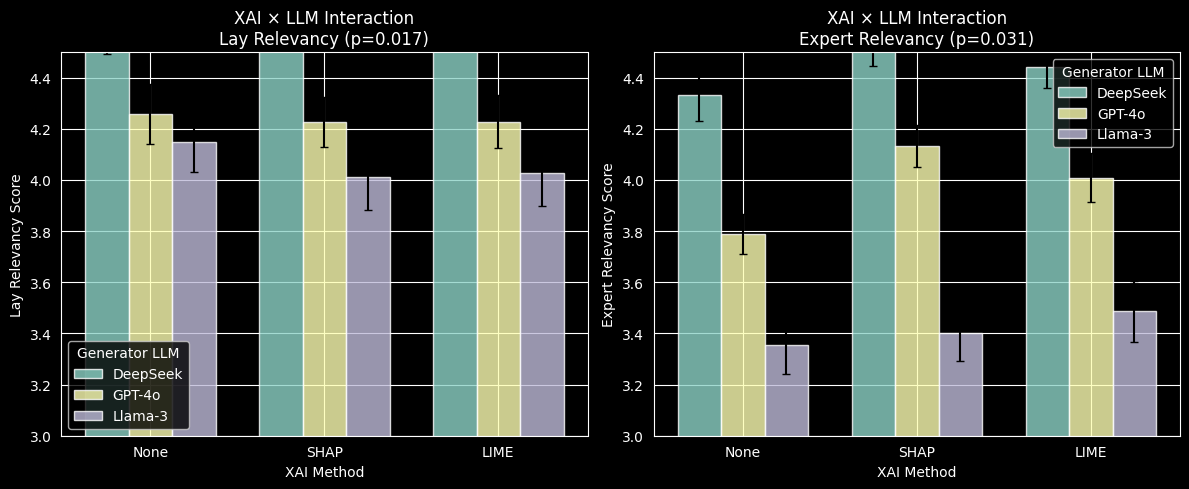


### Simple Effects: XAI effect within each LLM ###

Lay Relevancy:
  GPT-4o      : F=0.11, p=0.893
      SHAP=4.23, LIME=4.23, None=4.26
  Llama-3     : F=1.40, p=0.248
      SHAP=4.01, LIME=4.03, None=4.15
  DeepSeek    : F=7.05, p=0.001*
      SHAP=4.84, LIME=4.81, None=4.61

Expert Relevancy:
  GPT-4o      : F=16.01, p=0.000*
      SHAP=4.13, LIME=4.01, None=3.79
  Llama-3     : F=1.36, p=0.258
      SHAP=3.40, LIME=3.49, None=3.35
  DeepSeek    : F=4.64, p=0.011*
      SHAP=4.51, LIME=4.44, None=4.33


In [27]:
# RQ1: Interaction Plots + Simple Effects
# ========================================

import matplotlib.pyplot as plt

# Only plot for dimensions with significant interactions
sig_interactions = [r for r in interaction_results if r['sig']]

if sig_interactions:
    print("="*80)
    print("FOR APPENDIX: Interaction Plots + Simple Effects")
    print("="*80)
    print(f"\nSignificant XAI×LLM interactions found for: {[r['dim'] for r in sig_interactions]}")
    
    # Create interaction plots
    fig, axes = plt.subplots(1, len(sig_interactions), figsize=(6*len(sig_interactions), 5))
    if len(sig_interactions) == 1:
        axes = [axes]
    
    LLM_NAMES_SHORT = {'GPT': 'GPT-4o', 'L3_LOCAL': 'Llama-3', 'DEEPSEEK': 'DeepSeek'}
    XAI_ORDER = ['none', 'shap', 'lime']
    LLM_ORDER = ['DEEPSEEK', 'GPT', 'L3_LOCAL']
    
    for ax, result in zip(axes, sig_interactions):
        col = result['col']
        dim = result['dim']
        
        # Compute means for interaction plot
        means = df_xai.groupby(['XAI', 'LLM'])[col].mean().unstack()
        sems = df_xai.groupby(['XAI', 'LLM'])[col].sem().unstack()
        
        # Reorder
        means = means.loc[XAI_ORDER, LLM_ORDER]
        sems = sems.loc[XAI_ORDER, LLM_ORDER]
        
        # Plot
        x = np.arange(len(XAI_ORDER))
        width = 0.25
        
        for i, llm in enumerate(LLM_ORDER):
            ax.bar(x + i*width, means[llm], width, 
                   yerr=1.96*sems[llm], capsize=3,
                   label=LLM_NAMES_SHORT[llm], alpha=0.8)
        
        ax.set_xlabel('XAI Method')
        ax.set_ylabel(f'{dim} Score')
        ax.set_title(f'XAI × LLM Interaction\n{dim} (p={result["p"]:.3f})')
        ax.set_xticks(x + width)
        ax.set_xticklabels(['None', 'SHAP', 'LIME'])
        ax.legend(title='Generator LLM')
        ax.set_ylim(3.0, 4.5)
    
    plt.tight_layout()
    plt.savefig('figures/rq1_interaction_xai_llm.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Simple effects: XAI effect within each LLM
    print("\n### Simple Effects: XAI effect within each LLM ###")
    
    for result in sig_interactions:
        col = result['col']
        dim = result['dim']
        print(f"\n{dim}:")
        
        for llm in ['GPT', 'L3_LOCAL', 'DEEPSEEK']:
            llm_data = df_xai[df_xai['LLM'] == llm]
            shap_llm = llm_data[llm_data['XAI'] == 'shap'][col]
            lime_llm = llm_data[llm_data['XAI'] == 'lime'][col]
            none_llm = llm_data[llm_data['XAI'] == 'none'][col]
            
            # One-way ANOVA within this LLM
            f_stat, p_val = f_oneway(shap_llm, lime_llm, none_llm)
            sig = "*" if p_val < 0.05 else ""
            
            print(f"  {LLM_NAMES_SHORT[llm]:12}: F={f_stat:.2f}, p={p_val:.3f}{sig}")
            print(f"      SHAP={shap_llm.mean():.2f}, LIME={lime_llm.mean():.2f}, None={none_llm.mean():.2f}")
else:
    print("No significant XAI×LLM interactions - skipping interaction plots.")

In [28]:
# RQ1: Generate LaTeX Table
# ==========================

def generate_xai_latex_table(df, score_cols, dim_names):
    """Generate LaTeX table for XAI comparison with Overall column, sorted by Overall."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{G-Eval scores by XAI condition (SARIMAX excluded). XAI provides marginal improvements; SHAP and LIME differ only on Expert Relevancy. Bold = best per column.}")
    lines.append(r"  \label{tab:xai_results}")
    lines.append(r"  \begin{tabular}{@{}lccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header with Avg. column (4 dimensions + avg)
    dim_short = ['Acc.', 'Lay', 'Exp.', 'Help.', 'Avg.']
    lines.append(r"    \textbf{XAI} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    means_only = df.groupby('XAI')[score_cols].mean()
    
    # Add Overall column
    means_only['Overall'] = means_only.mean(axis=1)
    
    # Find best (highest) per column
    best_per_dim = means_only.idxmax()
    
    # Sort by Overall descending
    means_only = means_only.sort_values('Overall', ascending=False)
    
    # Display names
    xai_display = {'shap': 'SHAP', 'lime': 'LIME', 'none': 'None'}
    
    # Rows
    for xai in means_only.index:
        row_parts = [xai_display.get(xai, xai)]
        for col in score_cols:
            mean = means_only.loc[xai, col]
            if best_per_dim[col] == xai:
                row_parts.append(f"\\textbf{{{mean:.2f}}}")
            else:
                row_parts.append(f"{mean:.2f}")
        # Add Overall
        overall = means_only.loc[xai, 'Overall']
        if best_per_dim['Overall'] == xai:
            row_parts.append(f"\\textbf{{{overall:.2f}}}")
        else:
            row_parts.append(f"{overall:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate LaTeX table
latex_xai_table = generate_xai_latex_table(df_xai, SCORE_COLS, DIM_NAMES)
print("LaTeX Table for RQ1 (XAI Effect) - 4 Dimensions:")
print("="*80)
print(latex_xai_table)

LaTeX Table for RQ1 (XAI Effect) - 4 Dimensions:
\begin{table}[t]
  \centering
  \small
  \caption{G-Eval scores by XAI condition (SARIMAX excluded). XAI provides marginal improvements; SHAP and LIME differ only on Expert Relevancy. Bold = best per column.}
  \label{tab:xai_results}
  \begin{tabular}{@{}lccccc@{}}
    \toprule
    \textbf{XAI} & \textbf{Acc.} & \textbf{Lay} & \textbf{Exp.} & \textbf{Help.} & \textbf{Avg.} \\
    \midrule
    LIME & \textbf{4.57} & 4.31 & 3.94 & 4.31 & \textbf{4.28} \\
    SHAP & 4.53 & \textbf{4.32} & \textbf{3.97} & 4.30 & 4.28 \\
    None & 4.49 & 4.31 & 3.78 & \textbf{4.38} & 4.24 \\
    \bottomrule
  \end{tabular}
\end{table}
